In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 93.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=0299fb88ee7aa367277402f7da9ea15f26b970131cf40cf1c4e7e4092a41b141
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


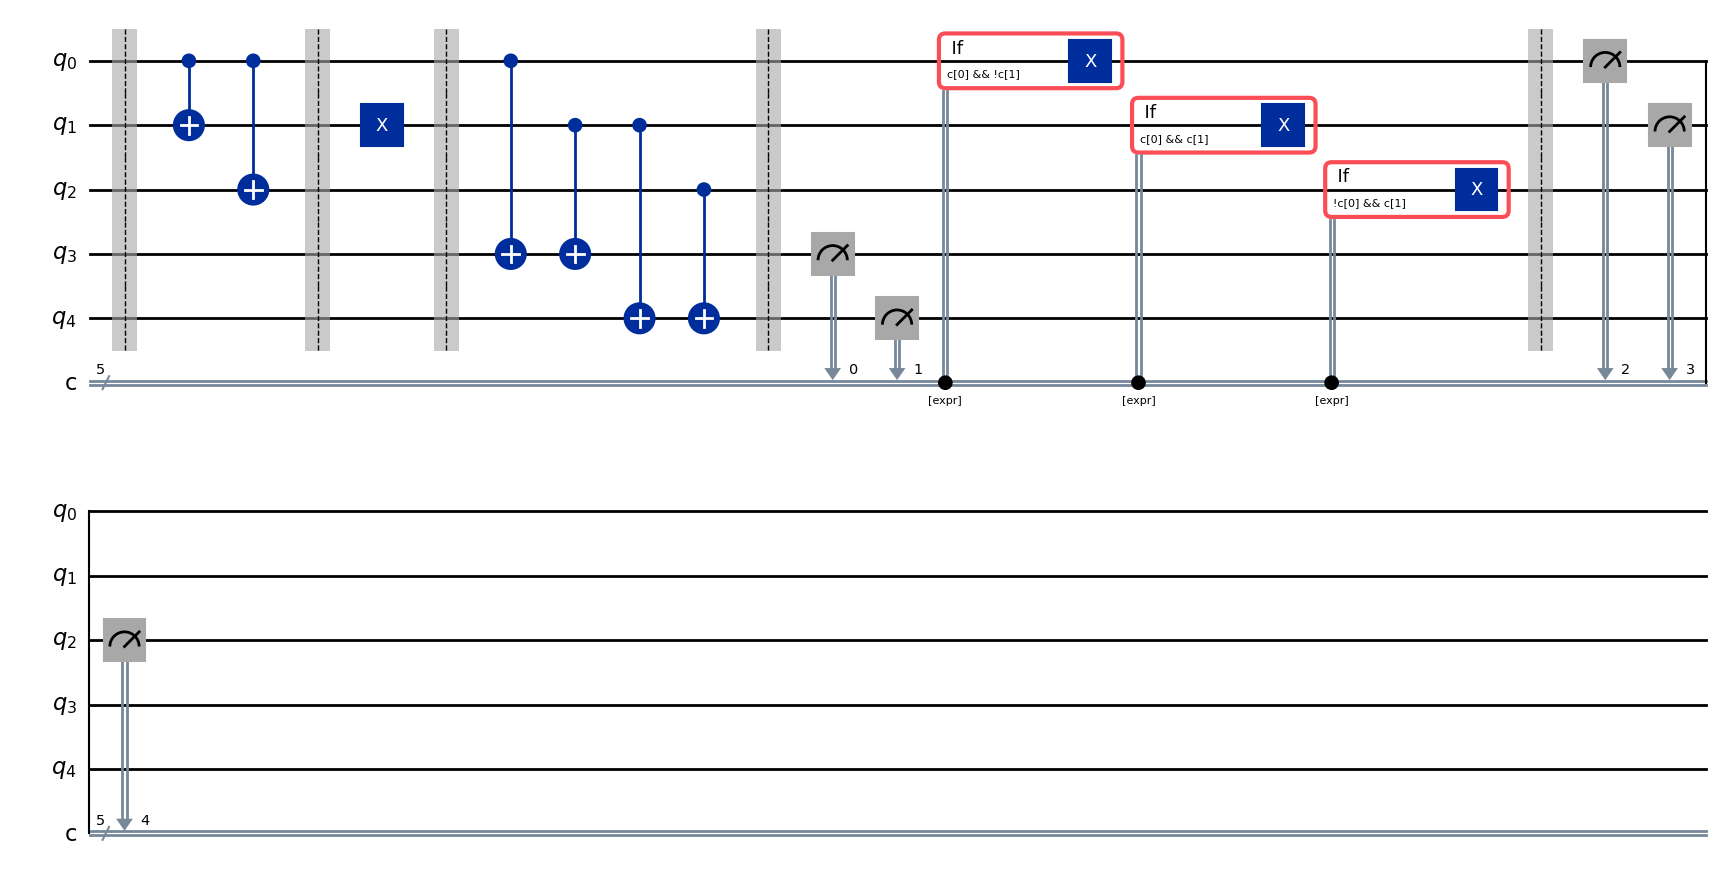

In [7]:
from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
from qiskit.circuit import ControlledGate
from qiskit.circuit.classical import expr
import math

# Three qubit bit-flip error-correcting code

flip = QuantumCircuit(5,5)

# qubit 0 is the one we are trying to send
# qubits 1 and 2 are used for the encoding
# qubits 3 and 4 are used for the error syndrome
# classical bits 0 and 1 are used for the syndrome measurement
# classical bits 2, 3 and 4 are for a final measurement to check the statistics

# flip.h(0)
# flip.x(0)

# Introduce barriers to help with visualisation

flip.barrier()

# Encode qubit 0 onto qubits 1 and 2

flip.cx(0,1)
flip.cx(0,2)

# Another barrier

flip.barrier()

# Add a bit-flip error
# Try errors on the other qubits, and check that the code corrects any single bit flip error.
# What happens if you flip two qubits?
# What happens if you introduce a phase flip error?

flip.x(1)

# Another barrier

flip.barrier()

# Syndrome measurements

flip.cx(0,3)
flip.cx(1,3)
flip.cx(1,4)
flip.cx(2,4)

flip.barrier()

flip.measure([3,4],[0,1])

# Conditional application of X to qubits 0, 1 and 2
# if c0 and not c1 then X(q0)
# if c0 and c1 then X(q1)
# if not c0 and c1 then X(q2)

with flip.if_test(expr.logic_and(flip.clbits[0],expr.logic_not(flip.clbits[1]))):
    flip.x(0)

with flip.if_test(expr.logic_and(flip.clbits[0],flip.clbits[1])):
    flip.x(1)

with flip.if_test(expr.logic_and(expr.logic_not(flip.clbits[0]),flip.clbits[1])):
    flip.x(2)

flip.barrier()

# The original state of qubit 0 was encoded by being "spread" across qubits 1 and 2.
# We are now back in that encoded state.
# Because of the entanglement, measuring qubits 0, 1 and 2
# should give the same statistics as measuring the original qubit 0.

# You can also implement the final decoding, putting the state back into a single qubit, and measuring it.

flip.measure([0,1,2],[2,3,4])

# Check the circuit

flip.draw("mpl")


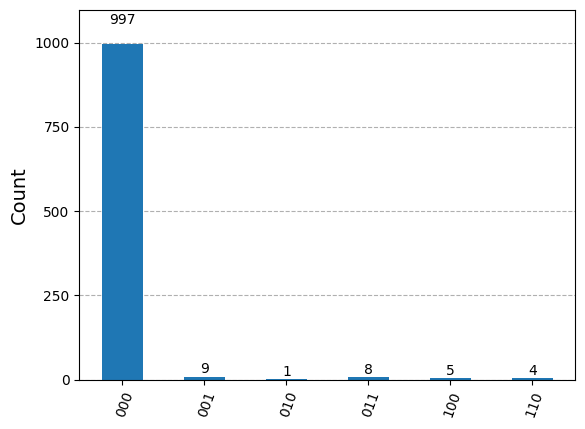

In [8]:
# Simulate and plot results
# Use GenericBackendV2 because we need if_test

backend = GenericBackendV2(num_qubits=5, control_flow=True)
compiled = transpile(flip, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
# We only want to see the results for bits 2, 3, 4
mcounts = marginal_counts(counts,indices=[2,3,4])
plot_histogram(mcounts)